# Introduzione alle reti neurali

In questa lezione vedremo una introduzione alle reti neurali e i fondamenti matematici che servono per comprendere e utilizzare le reti neurali.

Partiremo dall'introdurre cosa è il "perceptron", vedremo il problema dello XOR e cercheremo di capire:

- la discesa del gradiente (vedi altro file con codice python di esempio)
- la retropropagazione.

Si consiglia per una introduzione divulgativa ma rigorosa (e per gli eventuali assenti) di vedere anche i seguenti video:
- Cosa è una rete neurale https://youtu.be/aircAruvnKk?si=pHYhC8jWmUA--t9P

- Discesa del gradiente https://youtu.be/IHZwWFHWa-w?si=BO-huKCzNT5snH8i

- Retropropagazione https://youtu.be/tIeHLnjs5U8?si=-4ksJFAAvkEPHKZg

- https://youtu.be/tIeHLnjs5U8?si=LkMgdhlISRkUoQgT

Ulteriore materiale utilizzato in questa lezione è disponibile qui:

https://sites.google.com/view/machine-learning-lm/


---
## **Animazione per comprendere più in profondità**

Nel sito https://playground.tensorflow.org/ è presente una animazione interattiva che mostra molto bene come una rete neurale si "allena" a riconoscere le classi di un dataframe (non banale ovvero non linearmente separabile) al variare del tipo di rete neurale e dei parametri.


# Il Perceptron: Cos’è e Come Funziona

Il **Perceptron** è uno dei primi algoritmi di machine learning per la **classificazione binaria**.

È stato introdotto nel 1958 da **Frank Rosenblatt** ed è ispirato al funzionamento dei neuroni biologici.

È il mattone fondamentale delle  **reti neurali artificiali**.

---

## Struttura del Perceptron

Un perceptron riceve:

* un vettore di input $x = (x_1, x_2, ..., x_n)$
* un vettore di pesi $w = (w_1, w_2, ..., w_n)$
* un bias $b$

### Formula matematica

Il perceptron calcola:

$$
z = w \cdot x + b
$$

$$
y = f(z)
$$

Dove la funzione di attivazione è la **funzione a gradino (step function)**:

$$
f(z) =
\begin{cases}
1 & \text{se } z \ge 0 \\\\
0 & \text{se } z < 0
\end{cases}
$$

---

## Intuizione Geometrica

Il perceptron separa i dati tramite una **retta (in 2D)** o un **iperpiano (in dimensioni superiori)**.

L’equazione della frontiera decisionale è:

$
w \cdot x + b = 0
$

Se i dati sono **linearmente separabili**, il perceptron può trovare una soluzione.

---

##  Algoritmo di Addestramento

Il training avviene così:

Per ogni esempio:

1. Calcola la predizione
2. Confronta con il valore reale
3. Aggiorna i pesi se c'è errore

Il centro è ovviamente capire come aggiornare i pesi ovvero la regola di aggiornamento.

Vedremo che la regola di aggiornamento dipende da un parametro in genere chiamato "learning rate" e dal gradiente (nonché da come è calcolata la "catena di derivate").

---

#  Implementazione Manuale in Python

### **to DO**

---

#  Visualizzazione della Frontiera Decisionale

```python
import matplotlib.pyplot as plt

def plot_decision_boundary(X, y, model):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title("Frontiera Decisionale del Perceptron")
    plt.show()

plot_decision_boundary(X, y, model)
```

---

#  Esempio 2: Usare Scikit-learn

```python
from sklearn.linear_model import Perceptron

clf = Perceptron(max_iter=1000, eta0=0.1)
clf.fit(X, y)

print("Predizioni:", clf.predict(X))
print("Pesi:", clf.coef_)
print("Bias:", clf.intercept_)
```

---

#  Limiti del Perceptron

Il perceptron **NON** può risolvere problemi non linearmente separabili.

Esempio classico: **XOR**

```python
# Dataset XOR
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_xor = np.array([0, 1, 1, 0])

model = Perceptron(learning_rate=0.1, epochs=20)
model.fit(X_xor, y_xor)

print("Predizioni XOR:", model.predict(X_xor))
```

Vedrai che non funziona correttamente.

---

# Perché non funziona su XOR?

Perché XOR **non è linearmente separabile**.

Serve una rete con:

* più neuroni
* almeno un **hidden layer**

Questo porterà alla nascita delle **reti neurali multilayer (MLP)**.


---



In [9]:

import numpy as np

class Perceptron:
    def __init__(self, learning_rate=0.1, epochs=100):
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])  # X.shape[1] = numero di colonne = numero di feature.
        self.bias = 0

        for _ in range(self.epochs):
            for i in range(len(X)):
                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = self.activation(linear_output)

                update = self.lr * (y[i] - y_pred)
                self.weights += update * X[i]
                self.bias += update

    def activation(self, x):
        return 1 if x >= 0 else 0

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias  # np.dot fa il prodotto scalare.
        return np.array([self.activation(x) for x in linear_output])

X = np.array([[0,0],[0,1],[1,0],[1,1]])

y = np.array([0,1,1,0])

p1 = Perceptron()
p1.fit(X, y)

X_test = np.array([
    [1,0],
    [0,1],
    [1,0],
    [1,1]
])
y_test = [1,1,1,0]
print(p1.predict(X_test))


[0 1 0 0]


Memo tavola AND

$$
\begin{array}{|c|c||c|}
\hline
\text{ A} & \text{ B} & \text{A AND B} \\
\hline
0 & 0 & 0 \\
\hline
0 & 1 & 0 \\
\hline
1 & 0 & 0 \\
\hline
1 & 1 & 1 \\
\hline
\end{array}
$$

In [ ]:

##  Test su un Dataset Semplice (AND logico)

# Dataset AND
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 0, 0, 1])

model = Perceptron(learning_rate=0.1, epochs=10)
model.fit(X, y)

predictions = model.predict(X)

print("Predizioni:", predictions)
print("Pesi:", model.weights)
print("Bias:", model.bias)


Predizioni: [0 0 0 1]
Pesi: [0.2 0.1]
Bias: -0.20000000000000004


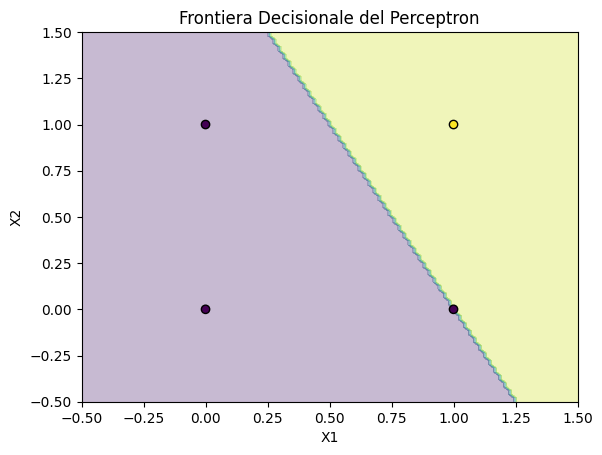

In [ ]:

import matplotlib.pyplot as plt

def plot_decision_boundary(X, y, model):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title("Frontiera Decisionale del Perceptron")
    plt.show()

plot_decision_boundary(X, y, model)


In [ ]:

# Dataset XOR
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_xor = np.array([0, 1, 1, 0])

model = Perceptron(learning_rate=0.1, epochs=20)
model.fit(X_xor, y_xor)

print("Predizioni XOR:", model.predict(X_xor))


Predizioni XOR: [1 1 0 0]


In [ ]:
from sklearn.linear_model import Perceptron

clf = Perceptron(max_iter=1000, eta0=0.1)
clf.fit(X, y)

print("Predizioni:", clf.predict(X))
print("Pesi:", clf.coef_)
print("Bias:", clf.intercept_)

Predizioni: [0 0 0 1]
Pesi: [[0.2 0.1]]
Bias: [-0.2]



# Il problema dello XOR (OR Esclusivo)

Lo **XOR** (Exclusive OR, ovvero "O esclusivo") è stata una delle sfide che hanno caratterizzato il Machine Learning, perché rappresenta il primo vero "ostacolo" che una rete neurale semplice non può superare.

A seguito della ricerca da Marvin Minsky e Seymour Papert nel loro influente libro Perceptrons del 1969 in cui dimostrarono il limite intrinseco di questo sistema iniziò uno periodo indicato come "inverno dell'Intelligenza Artificiale".


##  Che cos'è lo XOR?

In logica booleana, lo **XOR** è un operatore che restituisce "Vero" (1) solo quando gli input sono **diversi** tra loro. Se gli input sono uguali, il risultato è "Falso" (0).

Immaginalo come una scelta al ristorante: "Puoi avere il dolce *o* l'amaro (ma non entrambi, e non puoi restare senza nulla)".

### Tabella della Verità

| Input A | Input B | Output (A XOR B) |
| --- | --- | --- |
| 0 | 0 | **0** |
| 0 | 1 | **1** |
| 1 | 0 | **1** |
| 1 | 1 | **0** |


Per capire bene, dobbiamo confrontarlo con l'OR classico (Inclusivo):

* **OR:** Mi va bene A, mi va bene B, mi vanno bene **anche entrambi**.
* **XOR:** Mi va bene A, mi va bene B, ma **mai entrambi insieme**.

---

##  Perché lo XOR è "famoso" nelle Reti Neurali?

Negli anni '60, si scoprì che un singolo neurone (il Perceptron) non era in grado di imparare la funzione XOR. Questo portò a un temporaneo declino della ricerca sull'IA (il cosiddetto "Inverno dell'IA").

**Il motivo è geometrico:**

* Un singolo neurone può tracciare solo una **linea retta** per separare i dati (linearmente separabili).
* Se provi a disegnare i punti dello XOR su un grafico, vedrai che non esiste una singola linea retta che possa separare gli 0 dagli 1.

---

##  Come risolviamo il problema?

Per risolvere lo XOR, abbiamo bisogno di **più neuroni** organizzati in strati.

1. Uno strato "nascosto" trasforma lo spazio dei dati (distorce il grafico).
2. Lo strato di output può finalmente tracciare la linea corretta.

> **In sintesi:** Lo XOR ci insegna che per problemi complessi (non lineari), una singola cellula non basta: serve una **Rete**.

---




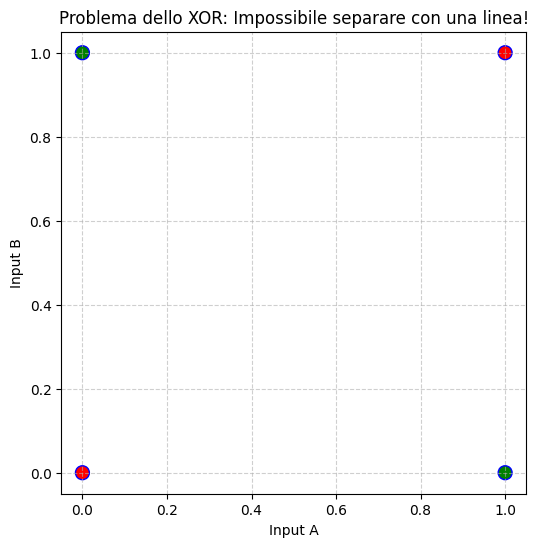

In [12]:
##  Codice Python: Visualizzare lo XOR
# script per vedere graficamente come sono distribuiti i punti dello XOR.

import matplotlib.pyplot as plt

# Dati dello XOR
x = [0, 1, 0, 1]
y = [0, 0, 1, 1]
colori = ['red', 'green', 'green', 'red'] # 0=Rosso, 1=Verde

plt.figure(figsize=(6,6))
plt.scatter(x, y, c=colori, s=100, edgecolors='blue')
# s sta per size, Controlla la dimensione dei punti.
# edgecolors = 'black', Significa: colore del bordo del punto.

plt.title("Problema dello XOR: Impossibile separare con una linea!")
plt.xlabel("Input A")
plt.ylabel("Input B")
plt.grid(True, linestyle='--', alpha=0.6)

# Nota: prova a immaginare di tirare una riga dritta che lasci i verdi
# da una parte e i rossi dall'altra... non ci riuscirai!
plt.show()


In [ ]:
import numpy as np

# Funzione di attivazione Sigmoide e la sua derivata
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# 1. Dataset di esempio (Input: 3 caratteristiche, Output: 1 target)
# Esempio: le prime due colonne determinano il risultato
X = np.array([[0,0,1],
              [1,1,1],
              [1,0,1],
              [0,1,1]])

y = np.array([[0], [1], [1], [0]])

# 2. Inizializzazione casuale dei pesi
np.random.seed(1)
# Pesi tra input layer (3 neuroni) e hidden layer (4 neuroni)
weights0 = 2 * np.random.random((3, 4)) - 1
# Pesi tra hidden layer (4 neuroni) e output layer (1 neurone)
weights1 = 2 * np.random.random((4, 1)) - 1

# 3. Ciclo di addestramento (Training)
for iteration in range(10000):

    # FORWARD PROPAGATION
    layer0 = X
    layer1 = sigmoid(np.dot(layer0, weights0))
    layer2 = sigmoid(np.dot(layer1, weights1))

    # BACKPROPAGATION
    # Calcolo dell'errore (Loss)
    layer2_error = y - layer2

    if (iteration % 2000) == 0:
        print(f"Errore iterazione {iteration}: {np.mean(np.abs(layer2_error))}")

    # Calcolo del gradiente per l'output layer
    layer2_delta = layer2_error * sigmoid_derivative(layer2)

    # Quanto ha contribuito il layer1 all'errore del layer2?
    layer1_error = layer2_delta.dot(weights1.T)
    layer1_delta = layer1_error * sigmoid_derivative(layer1)

    # Aggiornamento dei pesi (Gradient Descent)
    weights1 += layer1.T.dot(layer2_delta)
    weights0 += layer0.T.dot(layer1_delta)

print("\nOutput dopo l'allenamento:")
print(layer2)

Errore iterazione 0: 0.46853432545806034
Errore iterazione 2000: 0.01209811882788332
Errore iterazione 4000: 0.008227317734746437
Errore iterazione 6000: 0.00659240776437381
Errore iterazione 8000: 0.005641272019557657

Output dopo l'allenamento:
[[0.00510229]
 [0.99437164]
 [0.99493875]
 [0.00421887]]


# Cenni: Ordinary least square e reti neurali

E' possibile dimostrare che il perceptron è equivalente al fare una regressione logistica (se funzione di attivazione non lineare come sigmoide) o ad una regressione semplice (senza funzione non lineare).

Ricordiamo qui la regressione lineare però nella sua notazine con le matrici.

Le matrici e (più in generale) i tensori sono fondamentali per comprendere alcune implementazioni del ML e del Deep Learning.


In regressione lineare:

$y = X\beta + \varepsilon$

Stima OLS:

$\hat \beta = (X^T X)^{-1} X^T y$

Predizione:

$\hat y = X\hat \beta$


---

Neurone senza attivazione

Un neurone calcola:

$\hat y = w^T x + b$

Se aggiungiamo una colonna di 1 per il bias:

$\tilde x = (1, x_1, ..., x_d)$

allora:

$\hat y = \tilde w^T \tilde x$

È esattamente lo stesso modello.


- Differenza tra OLS e neurone


Se la loss è MSE, stiamo minimizzando:

$L(w) = \frac{1}{2}||Xw - y||^2$

La rete con un neurone sta facendo la stessa identica cosa.

 Un neurone è regressione lineare addestrata con GD invece che formula chiusa.


---

 PARTE 2 — Perché più layer lineari collassano

Supponiamo:

$h = XW_1$

$\hat y = hW_2$

Allora:

$\hat y = XW_1W_2$

Definiamo:

$W = W_1W_2$

Otteniamo:

$\hat y = XW$

Ancora lineare.

 Qualsiasi numero di layer lineari è equivalente a un singolo layer lineare.

Quindi senza attivazione:

$\text{Deep network} = \text{OLS}$


---

# Importanza della  non linearità

Ora inseriamo sigmoid o ReLU:

$\hat y =
W_2 \sigma(W_1 x + b_1) + b_2$

Adesso non possiamo più combinare i pesi.

La funzione non è più lineare in .

Ed è qui che nasce la magia.


---

# Perché una rete è Universal Approximator


Il concetto di fondo è capire che  una rete con:

- 1 hidden layer

- attivazione non lineare (sigmoid, ReLU, tanh)


può approssimare qualsiasi funzione continua su un compatto
con sufficiente numero di neuroni.


Per approfondire:
 https://en.wikipedia.org/wiki/Universal_approximation_theorem


Per una spiegazione più divulgativa si veda qui: https://youtu.be/O45AaRPQhuI?si=VqpzDZ_1JgfhRjsc


---

 Forma generale rete 1 hidden layer

$f(x) =
\sum_{j=1}^{m}
\alpha_j
\sigma(w_j^T x + b_j)$

È una somma di funzioni non lineari.


---

# Intuizione geometrica

Ogni neurone hidden crea una "curva" nello spazio.

Combinandone tante:

possiamo costruire gradini

poi combinare gradini → forme complesse

poi combinare forme → qualsiasi funzione continua


È come approssimare una funzione con:

onde sigmoidali

oppure funzioni a tratti (ReLU)


#  Intuizione più tecnica

La sigmoid può approssimare una funzione gradino.

Somma di gradini → funzione a tratti.

Funzioni a tratti → approssimano qualunque funzione continua.


---

# Differenza fondamentale con OLS

OLS può solo fare:

$\text{funzione lineare}$

Rete neurale può fare:

$\text{composizione non lineare}$

che genera superfici arbitrarie.


---

#Concetto profondo

Deep learning non è un qualcosa di magico...dietro c'è molta matematica.


**Nota importante:**

Universal approximator NON significa:

- che la rete impara sempre

- che bastano pochi neuroni

- che l’ottimizzazione è facile


Significa solo:

> Esiste una configurazione dei pesi che approssima la funzione.


# il meccanismo matematico che permette alla backpropagation di esistere.


Se una variabile dipende da un’altra, che dipende da un’altra ancora:

$
x \rightarrow g(x) \rightarrow f(g(x))
$

per derivare la funzione finale rispetto a (x), devi moltiplicare le derivate lungo il percorso.

$
\frac{df}{dx} = \frac{df}{dg} \cdot \frac{dg}{dx}
$
---

# Caso 1 variabile:

Supponiamo:

$
y = f(g(x))
$

Esempio concreto:

$
g(x) = x^2
$
$
f(g) = \sin(g)
$

Quindi:

$
y = \sin(x^2)
$

Derivata:

$\frac{dy}{dx} = 2x \cos(x^2)$

Perché?

1. Derivi l’esterno →  $\cos(x^2)$
2. Moltiplichi per la derivata dell’interno → $2x$

---

Se:
$z = f(y)$ e  $y = g(x)$

Allora:
$\frac{dz}{dx} = \frac{dz}{dy} \cdot \frac{dy}{dx}$

---

# Versione per più livelli (come nelle reti neurali)

Se hai:

$
x \rightarrow a \rightarrow b \rightarrow c
$

Allora:


$\frac{dc}{dx} = \frac{dc}{db} \cdot \frac{db}{da} \cdot \frac{da}{dx}$

Per semplicità abbiamo usato il simbolo della derivata normale e non parziale.

Questa è una **catena di moltiplicazioni di gradienti**.

---

#  Collegamento con la rete neurale

Nel nostro esempio:

$
X \rightarrow z_1 \rightarrow a_1 \rightarrow z_2 \rightarrow \hat{y} \rightarrow L
$

Se vogliamo:

$
\frac{\partial L}{\partial W_1}
$

dobbiamo attraversare tutta la catena:


$X \xrightarrow{W_1} z_1 \xrightarrow{\sigma} a_1 \xrightarrow{W_2} z_2 \xrightarrow{\text{softmax}} \hat{y} \xrightarrow{\text{loss}} L$


$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z_2} \cdot \frac{\partial z_2}{\partial a_1} \cdot \frac{\partial a_1}{\partial z_1} \cdot \frac{\partial z_1}{\partial W_1}$


Questa in sostanza è la backpropagation.
Il problema è capire la notazione e il fatto che siamo in uno spazio n-dimensionale.
A questo livello l'importante è concentrarsi sull'idea.

Le librerie Keras e PyTorch di Python faranno la derivazione per noi in modo corretto e automatico.



---

#  Intuizione Geometrica

La regola della catena ci aiuta a capire quanto cambia l’errore finale se cambio un peso iniziale.

In particolare si ha che:

> Dipende da quanto quel peso influenza il layer successivo,
> che influenza il successivo,
> che influenza il successivo…

È una sorta di "propagazione dell’influenza".

---

#  Versione Multivariata

Si inserisce la versione multivariata.

Se abbiamo:
$\begin{cases}
L = f(z_2) \\
z_2 = g(a_1) \\
a_1 = h(z_1) \\
z_1 = k(W_1)
\end{cases}$


$\nabla_{W_1} L = \nabla_{z_2} L \cdot \nabla_{a_1} z_2 \cdot \nabla_{z_1} a_1 \cdot \nabla_{W_1} z_1$

Spesso viene usata la notazione delle derivate parziali perché ritenuta più chiara rispetto al Nabla.

$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial z_2} \cdot \frac{\partial z_2}{\partial a_1} \cdot \frac{\partial a_1}{\partial z_1} \cdot \frac{\partial z_1}{\partial W_1}$


# Esempio rete neurale


Creiamo una rete neurale completamente da zero in NumPy, con:

1 input layer

1 hidden layer con 2 neuroni

1 output neurone

Backpropagation manuale

Gradient descent



In [ ]:
import numpy as np

# ==========================
#  Dataset semplice (XOR)
# ==========================

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([[0], [1], [1], [0]])

# ==========================
#  Funzioni utili
# ==========================

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
  """ si veda/riveda derivata della sigmoide"""
  return a * (1 - a)

# ==========================
#  Inizializzazione pesi
# ==========================

np.random.seed(42)

W1 = np.random.randn(2, 2)   # 2 input → 2 neuroni hidden
print("W1",W1)
b1 = np.zeros((1, 2))
print("b1",b1)

W2 = np.random.randn(2, 1)   # 2 hidden → 1 output
b2 = np.zeros((1, 1))
print("b2",b2)
learning_rate = 0.1
epochs = 10000

# ==========================
# Training
# ==========================

for epoch in range(epochs):

    #  Forward pass
    # qui simbolo @ è operatore di moltiplicazioni
    # fra matrici

    z1 = X @ W1 + b1
    a1 = sigmoid(z1)

    z2 = a1 @ W2 + b2
    y_hat = sigmoid(z2)

    #  Loss (MSE)
    loss = np.mean((y - y_hat)**2)

    # Backpropagation

    # Output layer gradient
    dL_dyhat = 2 * (y_hat - y) / y.shape[0]
    dyhat_dz2 = sigmoid_derivative(y_hat)
    dz2 = dL_dyhat * dyhat_dz2

    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    # Hidden layer gradient
    dz1 = dz2 @ W2.T * sigmoid_derivative(a1)

    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    #keepdims=True (che sta per "keep dimensions", ovvero "mantieni le dimensioni")
    #serve a impedire che la dimensione su cui stai facendo la somma "scompaia".
    # Nelle reti neurali, questo è fondamentale per evitare errori di forma (shape errors)

    #  Aggiornamento pesi
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    #  Stampa ogni 1000 epoche
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# ==========================
#  Test finale
# ==========================

print("\nPredizioni finali:")
print(y_hat.round(3))

W1 [[ 0.49671415 -0.1382643 ]
 [ 0.64768854  1.52302986]]
b1 [[0. 0.]]
b2 [[0.]]
Epoch 0, Loss: 0.2558
Epoch 1000, Loss: 0.2498
Epoch 2000, Loss: 0.2494
Epoch 3000, Loss: 0.2484
Epoch 4000, Loss: 0.2454
Epoch 5000, Loss: 0.2342
Epoch 6000, Loss: 0.2046
Epoch 7000, Loss: 0.1720
Epoch 8000, Loss: 0.1532
Epoch 9000, Loss: 0.1438

Predizioni finali:
[[0.124]
 [0.481]
 [0.891]
 [0.508]]


# Esempi con Keras e Pytorch